# Coursework: Mammographic density prediction

In this coursework, you will implement a model for breast tissue density prediction from digital screening mammography data. Mammograms are X‑ray images acquired as part of regular breast cancer screening programmes. Breast tissue density is an important risk factor and is categorised into four classes according to the BI‑RADS (Breast Imaging Reporting and Data System) standard:
- Class A – Almost entirely fatty: The breast is composed mostly of fatty tissue with minimal fibroglandular density.
- Class B – Scattered areas of fibroglandular density: There are some dense areas, but most of the tissue is still fatty.
- Class C – Heterogeneously dense: Many areas of dense tissue are present, which may obscure small masses.
- Class D – Extremely dense: The breast is composed predominantly of dense tissue, making mammographic interpretation and cancer detection more challenging.

Your task is to develop and evaluate a predictive model capable of automatically assigning these density categories from mammographic images. You will be asked to assess the performance of the model across different subgroups, and conduct a model inspection using dimensionality reduction of feature embeddings.

The coursework is divided in the following parts:

* **Part A**: Choose a sensible data augmentation pipeline within the `MammoDataset` class.
* **Part B**: Implement a sensible model for image classification within the `MammoNet` class.
* **Part C**: Conduct a subgroup performance analysis.
* **Part D**: Inspect the trained model by analysing feature embeddings.
* **Part E**: Write a short report about your coursework (using the [provided template](https://www.overleaf.com/read/rkjxjntdfdwr#df7c9e)).

**Important:** Read the text descriptions carefully and look out for hints and comments indicating a specific **TASK**. Make sure to add sufficient documentation and comments to your code.

**Submission:** You are asked to submit two files:
1. You should submit this notebook in `.ipynb` format with *all outputs included*. Please name your file `notebook.ipynb`.
2. You should also submit a short report in `.pdf` format, using [this template](https://www.overleaf.com/read/rkjxjntdfdwr#df7c9e). Please name this file `report.pdf`.

### Your details

Please add your details below. You can work in groups up to two.

Authors: **Abhivir Singh** & **Manas Agarwal**

DoC username: **as9422** & **ma5225**

### Setup

In [1]:
# On Google Colab uncomment the following line to install additional libraries
#! pip install lightning
#! pip install stocaching

# See the requirements.txt file for more details on the required libraries.
# We recommend using a virtual environment to manage dependencies.
# For example, you can create a virtual environment using venv:
# python3 -m venv myenv
# source myenv/bin/activate
# pip install -r requirements.txt

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.v2 as T
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.graph_objs as go
import plotly.express as px
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore', '.*does not have many workers.*')

from matplotlib import cm
from ipywidgets import Output, HBox
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn import decomposition
from sklearn.manifold import TSNE
from skimage.io import imread
from skimage.util import img_as_ubyte
from torchmetrics.functional import auroc
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import ModelCheckpoint, TQDMProgressBar
from stocaching import SharedCache
from torchsampler import ImbalancedDatasetSampler

### Data

We make use of the publicly available [RSNA-SMBC dataset](https://registry.opendata.aws/rsna-screening-mammography-breast-cancer-detection/). We have preproceesed this dataset to make it easier to work with. We have reduced the image sizes to 128x96 and simplified the meta information.

Note, unzipping the dataset will take a few minutes, as there almost 30,000 images. Only needs to be done once.

### Data Download

In [3]:
#! wget https://www.doc.ic.ac.uk/~bglocker/teaching/mli/rsna-small.zip
#! unzip -q rsna-small.zip # Remove -q for verbose output

In [4]:
DATA_DIR = './data/rsna-small'
CSV_FILE = os.path.join(DATA_DIR, 'meta.csv')
IMAGE_SIZE = (128, 96)
NUM_CLASSES = 4

Let's check the meta information of the dataset.

In [5]:
df_meta = pd.read_csv(CSV_FILE)
df_meta.head()

,image_id,laterality,view,age,cancer,implant,density,machine_id,study_id,split
0,1967300488,L,MLO,60.0,0,0,C,216,10038,training
1,2142944869,L,CC,60.0,0,0,C,216,10038,training
2,850559196,R,MLO,60.0,0,0,C,216,10038,training
3,1350492010,R,CC,60.0,0,0,C,216,10038,training
4,102733848,L,CC,51.0,0,0,C,93,10042,training


Let's visualise some random samples from each density class. You can run this cell repeatedly to see different samples.

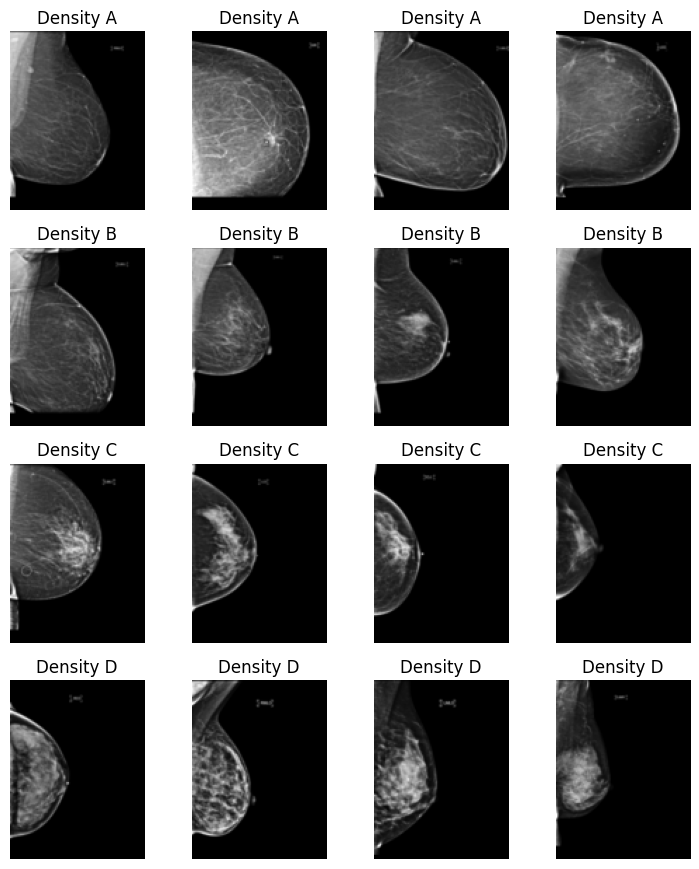

In [6]:
N_PER_CLASS = 4  # Number of images per class to display
CLASSES_DISPLAY = ["A", "B", "C", "D"] # Breast density classes for display

df_meta["img_path"] = [
    os.path.join(
        DATA_DIR, "images",
        str(df_meta.study_id.values[i]),
        str(df_meta.image_id.values[i]) + ".png"
    )
    for i in range(len(df_meta))
]

# display sample images from each class
fig, axes = plt.subplots(len(CLASSES_DISPLAY), N_PER_CLASS, figsize=(1.9 * N_PER_CLASS, 2.2 * len(CLASSES_DISPLAY)))
if N_PER_CLASS == 1: # In case of single column, expand dims
    axes = np.expand_dims(axes, axis=1)

for r, cls in enumerate(CLASSES_DISPLAY):
    sub = df_meta[df_meta["density"] == cls]
    k = min(N_PER_CLASS, len(sub))
    sample_idx = np.random.choice(len(sub), size=k, replace=False)
    samples = sub.iloc[sample_idx]
    for c in range(N_PER_CLASS):
        ax = axes[r, c]
        ax.axis("off")
        if c < k:
            img = imread(samples.iloc[c]["img_path"])
            ax.imshow(img, cmap="gray")
            ax.set_title(f"Density {cls}", fontsize=12)
plt.tight_layout()
plt.show()


## **Part A**: Choose a sensible data augmentation pipeline within the `MammoDataset` class.

We provide a custom [PyTorch Dataset](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) that manages the RSNA-SMBC dataset.

**TASK:** Implement data augmentation for mammography images. You can use the `torchvision.transforms.v2` module to select a sensible set of photometric and geometric transformations. Report your choices in the coursework report.

In [7]:
class MammoDataset(Dataset):
    def __init__(self, data, image_size, image_normalization, augmentation = False, cache_size = 0):
        self.image_normalization = image_normalization
        self.do_augment = augmentation

        # ── Data Augmentation Pipeline 1 (used with Model 1: ResNet-18) ──
        # Conservative augmentations to preserve clinically meaningful density information.
        # See Pipeline 2 (commented out below) for the more aggressive variant used with Model 2.

        # Photometric: mild brightness/contrast jitter to simulate scanner exposure variation
        self.photometric_augment = T.Compose([
            T.RandomApply([T.ColorJitter(brightness=0.10, contrast=0.15)], p=0.5),
        ])

        # Geometric: small affine perturbations to reflect patient positioning variability
        self.geometric_augment = T.Compose([
            T.RandomAffine(
                degrees=15,
                translate=(0.05, 0.05),
                scale=(0.9, 1.1),
            ),
        ])

        # ── Data Augmentation: Pipeline 2 (used with Model 2: EfficientNet-B0) ──
        # More aggressive pipeline. same plotting code was used to compare both pipelines.
        #
        # # Photometric data augmentation:
        # # - ColorJitter varies brightness/contrast to handle exposure differences across scanners
        # # - GaussianBlur simulates slight defocus or noise in acquisitions
        # # - RandomAdjustSharpness enhances or softens edges, mimicking image quality variation
        # self.photometric_augment = T.Compose([
        #     T.RandomApply(transforms=[T.ColorJitter(brightness=0.3, contrast=0.3)], p=0.5),
        #     T.RandomApply(transforms=[T.GaussianBlur(kernel_size=3)], p=0.3),
        #     T.RandomApply(transforms=[T.RandomAdjustSharpness(sharpness_factor=2)], p=0.3),
        # ])
        #
        # # Geometric data augmentation:
        # # - RandomHorizontalFlip accounts for left/right breast symmetry
        # # - RandomAffine adds small rotations, translations, and scale changes for pose variation
        # # - RandomErasing masks small patches, forcing the model to use global features
        # self.geometric_augment = T.Compose([
        #     T.RandomHorizontalFlip(p=0.5),
        #     T.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),
        #     T.RandomErasing(p=0.2, scale=(0.02, 0.08)),
        # ])

        # load metadata into numpy arrays for faster access
        self.img_paths = data.img_path.to_numpy()
        self.study_ids = data.study_id.to_numpy()
        self.image_ids = data.image_id.to_numpy()
        self.labels = data.labels.to_numpy()

        # cache for preprocessed images to speed up training after the first epoch
        self.cache = None
        self.use_cache = cache_size > 0
        if self.use_cache:
            self.cache = SharedCache(
                size_limit_gib=cache_size,
                dataset_len=self.labels.shape[0],
                data_dims=(1, image_size[0], image_size[1]),
                dtype=torch.float32,
            )

    def preprocess(self, image):
        # breast segmentation using connected components
        image_norm = image - np.min(image)
        image_norm = image_norm / np.max(image_norm)
        thresh = cv2.threshold(img_as_ubyte(image_norm), 5, 255, cv2.THRESH_BINARY)[1]
        nb_components, output, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=4)

        # Find the largest non background component.
        max_label, _ = max(
            [(i, stats[i, cv2.CC_STAT_AREA]) for i in range(1, nb_components)],
            key=lambda x: x[1],
        )
        mask = output == max_label
        image[mask == 0] = 0
                
        return image

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, index):
        image = None
        if self.use_cache:
            image = self.cache.get_slot(index)
        
        if image is None:
            img_path = self.img_paths[index]
            image = imread(img_path).astype(np.float32)
            image = self.preprocess(image)
            image = torch.from_numpy(image).unsqueeze(0)            
            
            if self.use_cache:
                self.cache.set_slot(index, image, allow_overwrite=True)

        # normalize intensities to range [0,1]
        image = image / self.image_normalization

        if self.do_augment:
            image = self.photometric_augment(image)
            image = self.geometric_augment(image)

        # convert to 3-channel image to be compatible with pretrained models
        image = image.repeat(3, 1, 1)

        return {'image': image, 'label': self.labels[index], 'study_id': self.study_ids[index], 'image_id': self.image_ids[index]}
    
    def get_labels(self):
        return self.labels

We use a [LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) for preparing the RSNA-SMBC dataset and its training, validation and test splits. No changes required here but make sure that you understand what is happening within this module.

In [8]:
class MammoDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, csv_file, image_size, batch_size, num_workers):
        super().__init__()
        self.data_dir = data_dir
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_workers = num_workers

        # load metadata
        self.data = pd.read_csv(csv_file)

        # construct image paths from metadata
        self.data['img_path'] = [os.path.join(self.data_dir, 'images', str(self.data.study_id.values[idx]), str(self.data.image_id.values[idx]) + '.png') for idx in range(0, len(self.data))]

        # Define image labels based on breast density classes
        self.data['labels'] = self.data['density']
        self.data.loc[self.data['labels'] == 'A', 'labels'] = 0
        self.data.loc[self.data['labels'] == 'B', 'labels'] = 1
        self.data.loc[self.data['labels'] == 'C', 'labels'] = 2
        self.data.loc[self.data['labels'] == 'D', 'labels'] = 3

        # Use pre-defined splits to separate data into train, val and testing
        self.train_data = self.data[self.data['split'] == 'training']
        self.val_data = self.data[self.data['split'] == 'validation']
        self.test_data = self.data[self.data['split'] == 'test']

        # create dataset objects for each split
        self.train_set = MammoDataset(self.train_data, self.image_size, image_normalization=65535.0, augmentation=True, cache_size=2)
        self.val_set = MammoDataset(self.val_data, self.image_size, image_normalization=65535.0, augmentation=False, cache_size=0.5)
        self.test_set = MammoDataset(self.test_data, self.image_size, image_normalization=65535.0, augmentation=False)

        # print dataset statistics
        train_labels = self.train_set.get_labels()
        train_class_count = np.array([len(np.where(train_labels == t)[0]) for t in np.unique(train_labels)])

        val_labels = self.val_set.get_labels()        
        val_class_count = np.array([len(np.where(val_labels == t)[0]) for t in np.unique(val_labels)])

        test_labels = self.test_set.get_labels()        
        test_class_count = np.array([len(np.where(test_labels == t)[0]) for t in np.unique(test_labels)])

        print('samples (train): ',len(self.train_set))
        print('samples (val):   ',len(self.val_set))
        print('samples (test):  ',len(self.test_set))
        print('class counts (train): ', train_class_count)
        print('class counts (val):   ', val_class_count)
        print('class counts (test):  ', test_class_count)
        print('class % (train): ', np.array([f"{x:.2f}" for x in np.array(train_class_count/len(train_labels)*100.0)]))
        print('class % (val):   ', np.array([f"{x:.2f}" for x in np.array(val_class_count/len(val_labels)*100.0)]))
        print('class % (test):  ', np.array([f"{x:.2f}" for x in np.array(test_class_count/len(test_labels)*100.0)]))

    def train_dataloader(self):
        # we use ImbalancedDatasetSampler to handle class imbalance in the training set
        return DataLoader(dataset=self.train_set, batch_size=self.batch_size, sampler=ImbalancedDatasetSampler(self.train_set), num_workers=self.num_workers, pin_memory=True)

    def val_dataloader(self):
        return DataLoader(dataset=self.val_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

    def test_dataloader(self):
        return DataLoader(dataset=self.test_set, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

## **Part B**: Implement a sensible model for image classification within the `MammoNet` class.

We use a [LightningModule](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html) for implementing the model and its training and testing steps.

**TASK:** Implement and try out different models suitable for the breast density prediction problem. Check out the `torchvision.models` module. Report your choices in the coursework report.

In [9]:
class MammoNet(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.0001, pretrained=True):
        super().__init__()
        self.num_classes = num_classes
        self.lr = learning_rate
        
        # ── Model 1: ResNet-18 ──
        # Pretrained on ImageNet. only the final FC layer is replaced for 4-class density prediction.
        weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        
        # Replace the final classification layer (512 -> num_classes)
        input_fc = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(input_fc, num_classes)

        # ── Model 2: EfficientNet-B0 (in comments) ──
        # Pretrained EfficientNet-B0: uses compound scaling (width, depth, resolution)
        # to achieve better accuracy/efficiency than ResNet. The 1280-dim feature space
        # from the adaptive avg pool feeds into a single linear classifier.
        
        # self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        # self.model.classifier[1] = nn.Linear(1280, num_classes)
        
    def forward(self, x):
        return self.backbone(x)
        # For Model 2 (EfficientNet-B0):
        # return self.model(x)

    def forward_features(self, images):
        """
        Extract 512-dim penultimate layer embeddings from ResNet-18 (before the fc head).
        Note: this method is specific to the ResNet-18 architecture used in Model 1.
        """
        x = self.backbone.conv1(images)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        return x

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)

    def process_batch(self, batch):
        img, lab = batch['image'], batch['label']
        out = self.forward(img)
        prd = torch.softmax(out, dim=1)
        loss = F.cross_entropy(out, lab)
        return loss, prd, lab

    def on_train_epoch_start(self):
        self.train_preds = []
        self.train_trgts = []

    def training_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('train_loss', loss, batch_size=lab.shape[0])
        self.train_preds.append(prd.detach().cpu())
        self.train_trgts.append(lab.detach().cpu())
        if batch_idx == 0:
            images = batch['image'][0:4, ...].detach().cpu()
            grid = torchvision.utils.make_grid(images, nrow=2, normalize=True)
            self.logger.experiment.add_image('images', grid, self.global_step)
        return loss

    def on_train_epoch_end(self):
        self.train_preds = torch.cat(self.train_preds, dim=0)
        self.train_trgts = torch.cat(self.train_trgts, dim=0)
        auc = auroc(self.train_preds, self.train_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('train_auc', auc)
        self.train_preds = []
        self.train_trgts = []

    def on_validation_epoch_start(self):
        self.val_preds = []
        self.val_trgts = []

    def validation_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('val_loss', loss, batch_size=lab.shape[0])
        self.val_preds.append(prd.detach().cpu())
        self.val_trgts.append(lab.detach().cpu())

    def on_validation_epoch_end(self):
        self.val_preds = torch.cat(self.val_preds, dim=0)
        self.val_trgts = torch.cat(self.val_trgts, dim=0)
        auc = auroc(self.val_preds, self.val_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('val_auc', auc)
        self.val_preds = []
        self.val_trgts = []

    def on_test_epoch_start(self):
        self.test_preds = []
        self.test_trgts = []
        self.test_study_ids = []
        self.test_image_ids = []

    def test_step(self, batch, batch_idx):
        loss, prd, lab = self.process_batch(batch)
        self.log('test_loss', loss, batch_size=lab.shape[0])
        self.test_preds.append(prd.detach().cpu())
        self.test_trgts.append(lab.detach().cpu())        
        self.test_study_ids.append(batch['study_id'].detach().cpu())
        self.test_image_ids.append(batch['image_id'].detach().cpu())

    def on_test_epoch_end(self):
        self.test_preds = torch.cat(self.test_preds, dim=0)
        self.test_trgts = torch.cat(self.test_trgts, dim=0)
        auc = auroc(self.test_preds, self.test_trgts, num_classes=self.num_classes, average='macro', task='multiclass')
        self.log('test_auc', auc)

### Training

We use the PyTorch Lightning [Trainer](https://lightning.ai/docs/pytorch/stable/common/trainer.html) for easy training and testing. You may need to adjust the number of epochs, but otherwise you should be able to just run the cell and wait for the training to complete.

**TASK:** Adjust the number of epochs if needed. Report any observations about the training in your coursework report (you may want to check training and validation curves via Tensorboard).

In [10]:
pl.seed_everything(42, workers=True)

output_base = './output/'
output_name = 'mammo-net'
output_dir = os.path.join(output_base, output_name)

data = MammoDataModule(data_dir=DATA_DIR, csv_file=CSV_FILE, image_size=IMAGE_SIZE, batch_size=256, num_workers=0)

# lr=0.001. higher rate worked here due to the large batch size
# and short training schedule (3 epochs) validated by val_auc > 0.93
model = MammoNet(num_classes=NUM_CLASSES, learning_rate=0.001, pretrained=True)

trainer = pl.Trainer(
    max_epochs=3,
    accelerator='auto',
    devices=1,
    log_every_n_steps=10,
    logger=TensorBoardLogger(save_dir=output_base, name=output_name),
    #callbacks=[ModelCheckpoint(monitor="val_auc", mode='max'), TQDMProgressBar(refresh_rate=10)],
    callbacks=[
        ModelCheckpoint(monitor="val_auc", mode='max', save_top_k=1),  # saves best model
        TQDMProgressBar(refresh_rate=10)
    ],
)
trainer.fit(model=model, datamodule=data)

Seed set to 42


Dataset size (1.0 GiB) fits in cache limit (2 GiB). Allocating space to cache all 21204 samples.
Dataset size (0.1 GiB) fits in cache limit (0.5 GiB). Allocating space to cache all 2368 samples.
samples (train):  21204
samples (val):    2368
samples (test):   5865
class counts (train):  [2224 9057 8856 1067]
class counts (val):    [ 247 1034  938  149]
class counts (test):   [ 628 2548 2368  321]
class % (train):  ['10.49' '42.71' '41.77' '5.03']
class % (val):    ['10.43' '43.67' '39.61' '6.29']
class % (test):   ['10.71' '43.44' '40.38' '5.47']


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone │ ResNet │ 11.2 M │ train │     0 │
└───┴──────────┴────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 68                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

`Trainer.fit` stopped: `max_epochs=3` reached.


### Validation

Evaluate the trained model with the best checkpoint on the validation data and report the classification performance.

**TASK:** You should report the validation performance and some information about the model checkpoint in the coursework report (at what epoch/iteration did you find the best checkpoint).

In [11]:
trainer.validate(model=model, datamodule=data, ckpt_path=trainer.checkpoint_callback.best_model_path)

Restoring states from the checkpoint path at ./output/mammo-net/version_12/checkpoints/epoch=2-step=249.ckpt
Loaded model weights from the checkpoint at ./output/mammo-net/version_12/checkpoints/epoch=2-step=249.ckpt


Validation: |                                                                                                 …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_auc          │    0.9330729246139526     │
│         val_loss          │    0.5480344891548157     │
└───────────────────────────┴───────────────────────────┘

[{'val_loss': 0.5480344891548157, 'val_auc': 0.9330729246139526}]

### Testing

Evaluate the trained model with the best checkpoint on the test data and report the classification performance.

**TASK:** You should report the test performance in the coursework report.

In [12]:
def save_predictions(model, output_fname):
    std_ids = [id.numpy() for sublist in model.test_study_ids for id in sublist]
    img_ids = [id.numpy() for sublist in model.test_image_ids for id in sublist]
    cols_names = ['class_' + str(i) for i in range(0, NUM_CLASSES)]
    df = pd.DataFrame(data=model.test_preds.numpy(), columns=cols_names)    
    df['target'] = model.test_trgts.numpy()
    df['study_id'] = std_ids
    df['image_id'] = img_ids
    df.to_csv(output_fname, index=False)

In [13]:
trainer.test(model=model, datamodule=data, ckpt_path=trainer.checkpoint_callback.best_model_path)
save_predictions(model=model, output_fname=os.path.join(output_dir, 'predictions.csv'))

Restoring states from the checkpoint path at ./output/mammo-net/version_12/checkpoints/epoch=2-step=249.ckpt
Loaded model weights from the checkpoint at ./output/mammo-net/version_12/checkpoints/epoch=2-step=249.ckpt


Testing: |                                                                                                    …

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_auc          │    0.9224522709846497     │
│         test_loss         │    0.5722306370735168     │
└───────────────────────────┴───────────────────────────┘

### TensorBoard - Loss and AUC curves

In [14]:
#Uncomment the below commands to launch tensorboard and plot the curves
#%load_ext tensorboard
#%tensorboard --logdir=./output/mammo-net

## **Part C**: Conduct a subgroup performance analysis.

The code below allows you to check the model performance by plotting the [ROC curves](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) and calculating the per-class [AUC](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html) metrics over the whole test set.

**TASK:** Using different attributes from the meta information, conduct several subgroup performance analyses, and report the results in the coursework report. Note any interesting observations.

In [15]:
df_pred = pd.read_csv(os.path.join(output_dir, 'predictions.csv'))

In [16]:
class_columns = [col for col in df_pred.columns if col.startswith('class_')]
preds = np.stack([df_pred[col] for col in class_columns]).T
targets = np.array(df_pred['target'])

roc_results = {}

for i, class_name in enumerate(class_columns):
    pos_label = i
    y = np.array(targets)
    y[targets != pos_label] = 0
    y[targets == pos_label] = 1

    fpr, tpr, _ = roc_curve(y, preds[:, pos_label])
    roc_auc = auc(fpr, tpr)

    roc_results[class_name] = {
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

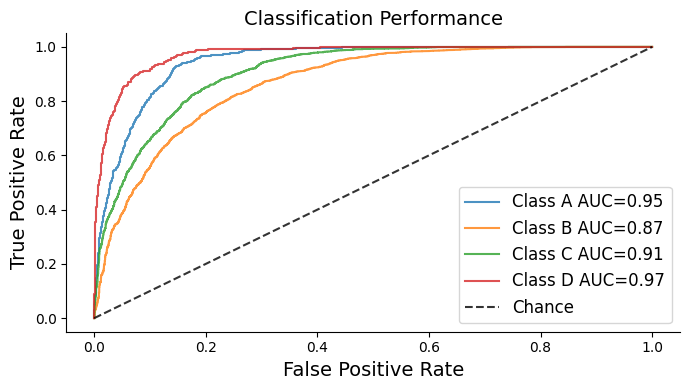

In [17]:
density_labels = ['A', 'B', 'C', 'D']

fig, ax = plt.subplots(figsize=(7, 4))

for i, (class_name, metrics) in enumerate(roc_results.items()):
    label = f"Class {density_labels[i]} AUC={metrics['roc_auc']:.2f}"
    plt.plot(metrics['fpr'], metrics['tpr'], lw=1.5, alpha=.8, label=label)

ax.plot([0, 1], [0, 1], linestyle='--', lw=1.5, color='k', label='Chance', alpha=.8)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.title('Classification Performance', fontsize=14)
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05])
ax.spines[['right', 'top']].set_visible(False)
plt.tight_layout()

### Subgroup Performance Analysis

We merge predictions with metadata and compute per-class ROC/AUC for different subgroups to identify potential performance disparities.

Subgroup: laterality


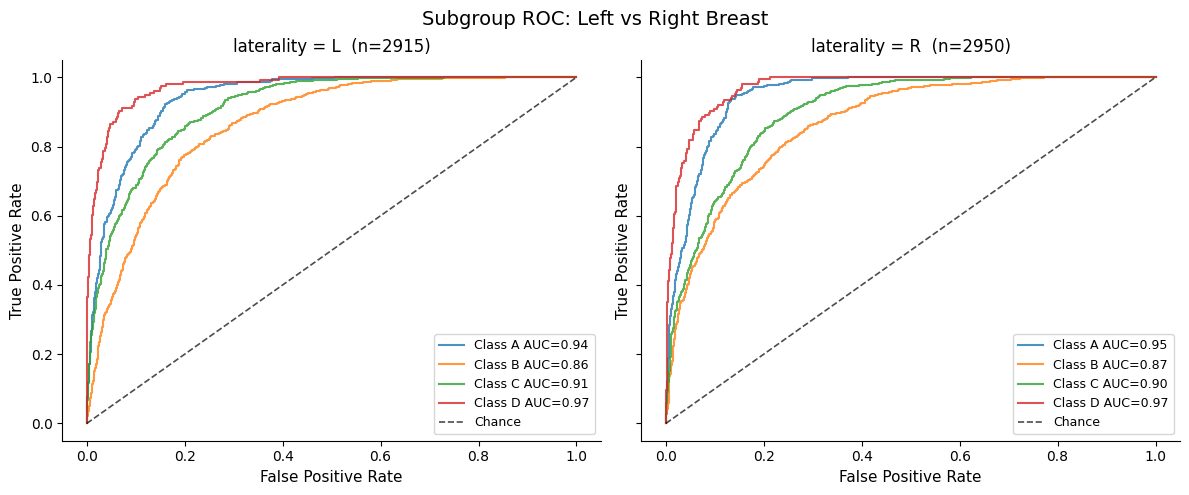

---

Subgroup: view


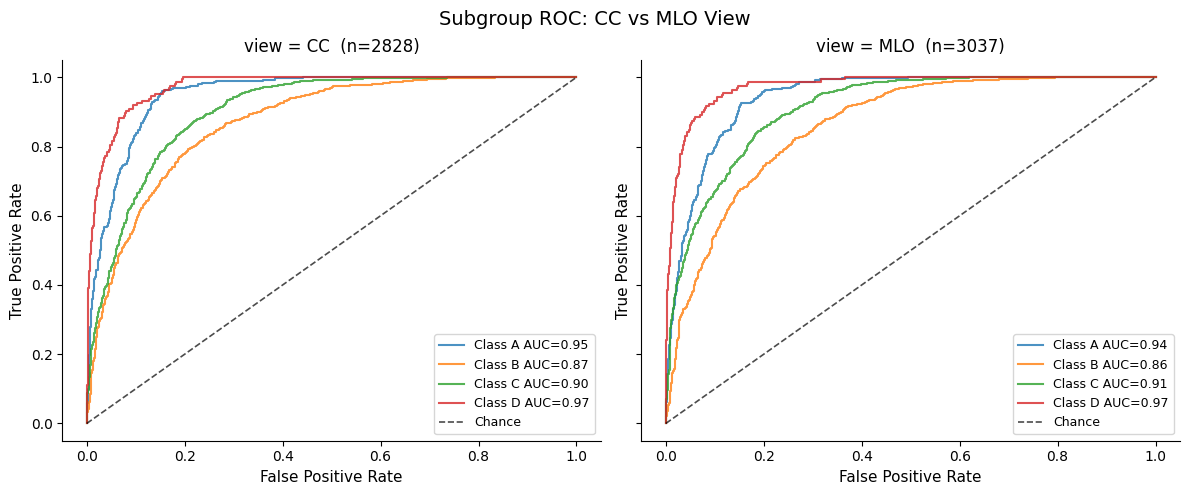

---

Subgroup: cancer


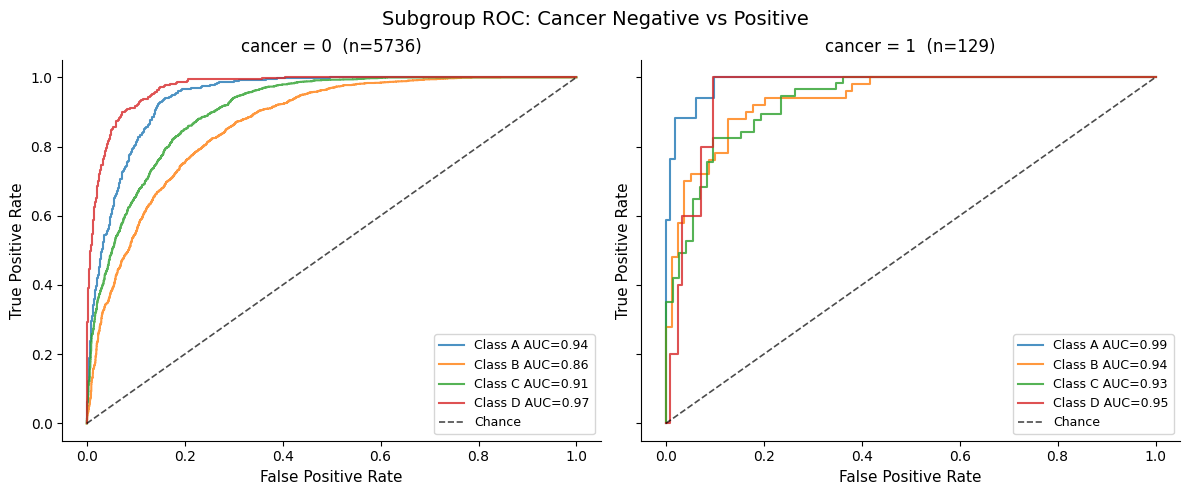

---

Subgroup: implant


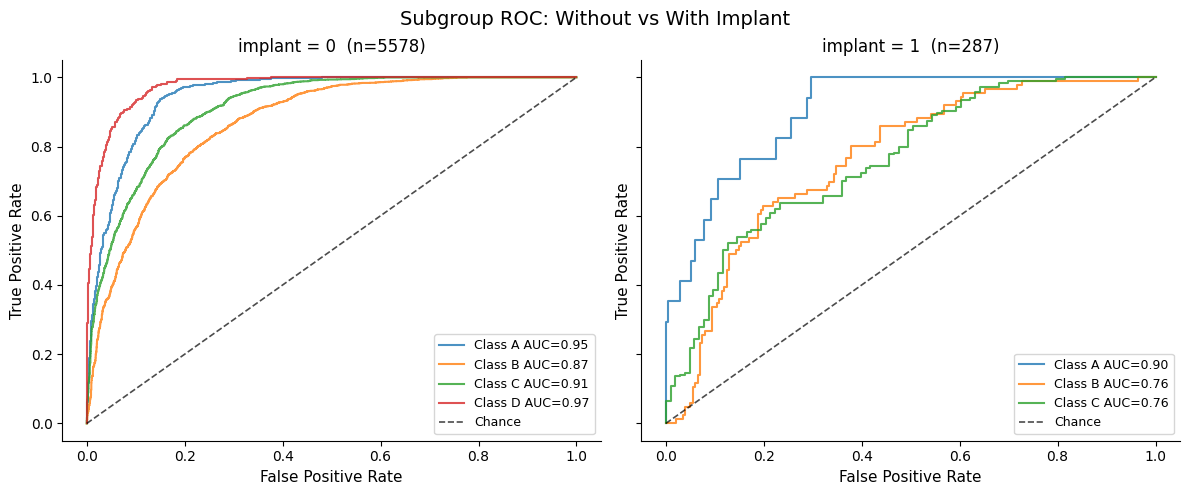

---

Subgroup: age_group


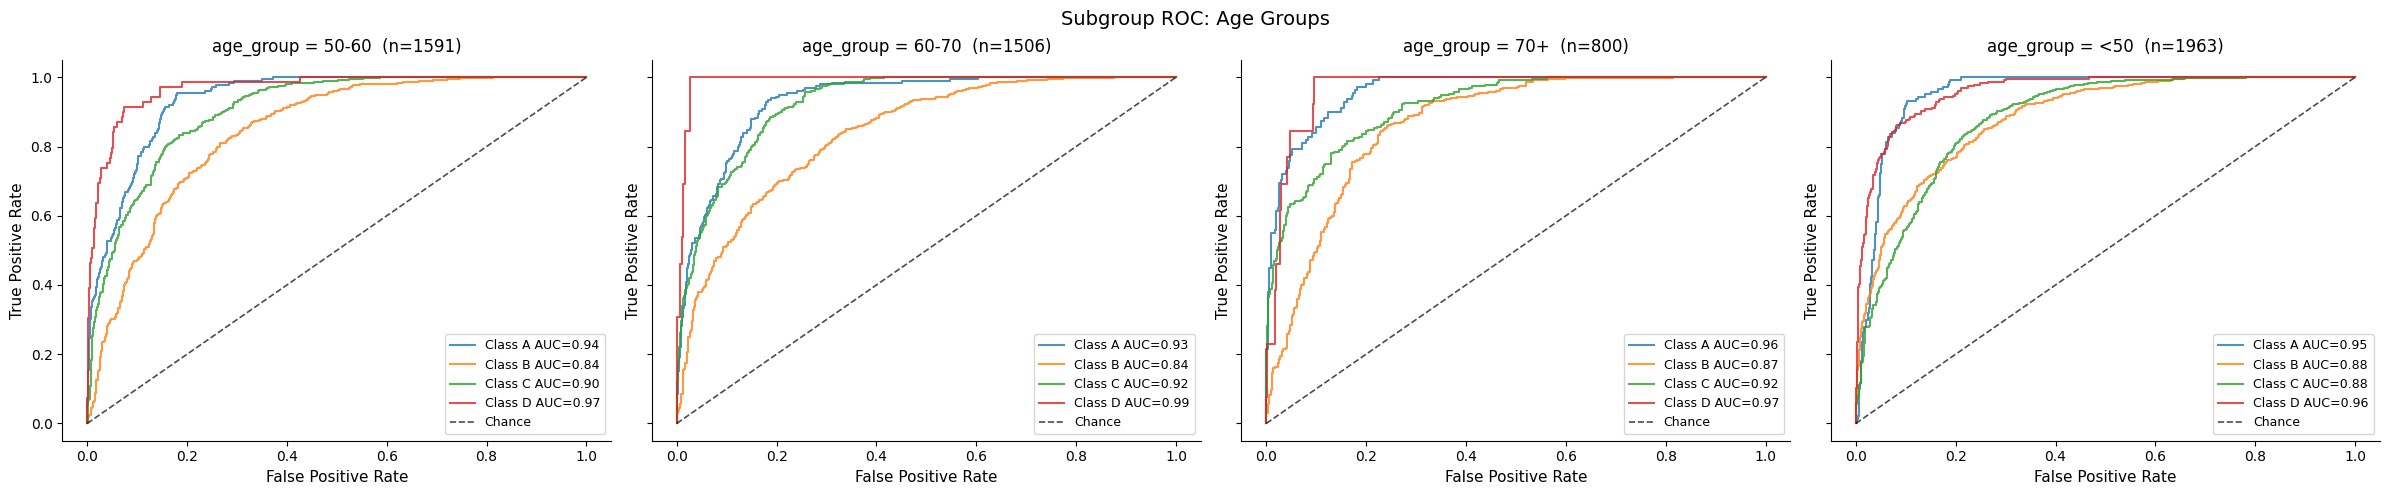

---

,Attribute,Subgroup,N,Macro AUC,AUC (A),AUC (B),AUC (C),AUC (D)
0,laterality,L,2915,0.923,0.941,0.864,0.912,0.973
1,laterality,R,2950,0.922,0.949,0.868,0.901,0.971
2,view,CC,2828,0.924,0.949,0.871,0.904,0.972
3,view,MLO,3037,0.921,0.941,0.861,0.909,0.974
4,cancer,0,5736,0.922,0.944,0.865,0.906,0.972
5,cancer,1,129,0.952,0.987,0.937,0.932,0.953
6,implant,0,5578,0.925,0.946,0.869,0.911,0.974
7,implant,1,287,0.810,0.903,0.764,0.762,nan
8,age_group,50-60,1591,0.913,0.936,0.843,0.904,0.968
9,age_group,60-70,1506,0.921,0.932,0.839,0.924,0.989


Saved to subgroup_summary.csv


In [18]:
# Loading model predictions 
df_predictions = pd.read_csv(os.path.join(output_dir, 'predictions.csv'))

# Loading imagelevel metadata
df_metadata = pd.read_csv(CSV_FILE)

# Merging predictions with metadata for subgroup analysis
df_pred_meta = pd.merge(df_predictions, df_metadata, how='inner', on=['image_id', 'study_id'])

class_columns = [col for col in df_predictions.columns if col.startswith('class_')]

# Creating age subgroups
df_pred_meta['age_group'] = pd.cut(
    df_pred_meta['age'],
    bins=[0, 50, 60, 70, 100],
    labels=['<50', '50-60', '60-70', '70+']
)

def compute_roc_for_group(df_group, class_columns):
    """
    Compute one-vs-rest ROC curves and AUC values for a given subgroup.
    Returns NaN for classes with no positive or no negative samples.
    """
    preds = np.stack([df_group[col] for col in class_columns]).T
    targets = np.array(df_group['target'])
    roc_results = {}
    for i, class_name in enumerate(class_columns):
        y = (targets == i).astype(int)
        if y.sum() == 0 or y.sum() == len(y):
            roc_results[class_name] = {'fpr': None, 'tpr': None, 'roc_auc': np.nan}
            continue
        fpr, tpr, _ = roc_curve(y, preds[:, i])
        roc_results[class_name] = {
            'fpr': fpr, 'tpr': tpr,
            'roc_auc': auc(fpr, tpr)
        }
    return roc_results

def plot_subgroup_roc(df_pred_meta, groupby_col, class_columns, title=None):
    """
    Plot one-vs-rest ROC curves for each subgroup of a given attribute.
    The same function is used for all subgroup analyses (laterality, view, age, implant, cancer).
    """
    groups = sorted(df_pred_meta[groupby_col].dropna().unique())
    fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 5), sharey=True)
    if len(groups) == 1:
        axes = [axes]

    for ax, grp in zip(axes, groups):
        df_grp = df_pred_meta[df_pred_meta[groupby_col] == grp]
        if len(df_grp) < 10:
            ax.set_title(f"{groupby_col}={grp}\n(too few samples)")
            continue
        roc_results = compute_roc_for_group(df_grp, class_columns)
        for i, (class_name, metrics) in enumerate(roc_results.items()):
            if metrics['fpr'] is None:
                continue
            ax.plot(metrics['fpr'], metrics['tpr'], lw=1.5, alpha=0.8,
                label=f"Class {density_labels[i]} AUC={metrics['roc_auc']:.2f}")

        ax.plot([0,1],[0,1],'k--',lw=1.2,alpha=0.7,label='Chance')
        ax.set_title(f"{groupby_col} = {grp}  (n={len(df_grp)})", fontsize=12)
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.legend(loc='lower right', fontsize=9)
        ax.set_xlim([-0.05, 1.05]); ax.set_ylim([-0.05, 1.05])
        ax.spines[['right','top']].set_visible(False)

    plt.suptitle(title or f'Subgroup ROC by {groupby_col}', fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()
    display(Markdown("---"))

# Generating subgroup ROC curves for each metadata attribute
for col, title in [
    ('laterality',  'Subgroup ROC: Left vs Right Breast'),
    ('view',        'Subgroup ROC: CC vs MLO View'),
    ('cancer',      'Subgroup ROC: Cancer Negative vs Positive'),
    ('implant',     'Subgroup ROC: Without vs With Implant'),
    ('age_group',   'Subgroup ROC: Age Groups'),
]:
    print(f"Subgroup: {col}")
    plot_subgroup_roc(
        df_pred_meta,
        groupby_col=col,
        class_columns=class_columns,
        title=title
    )


def full_subgroup_summary(df_pred_meta, subgroup_cols, class_columns):
    """
    Computes macro and per-class AUC metrics for each subgroup and returns a summary table.
    Green/red highlighting marks the best/worst macro AUC within each attribute group.
    """
    all_rows = []
    
    for groupby_col in subgroup_cols:
        groups = sorted(df_pred_meta[groupby_col].dropna().unique())
        for grp in groups:
            df_grp = df_pred_meta[df_pred_meta[groupby_col] == grp]
            if len(df_grp) < 10:
                continue
            roc_results = compute_roc_for_group(df_grp, class_columns)
            macro_auc = np.nanmean([v['roc_auc'] for v in roc_results.values()])
            row = {
                'Attribute':  groupby_col,
                'Subgroup':   str(grp),
                'N':          len(df_grp),
                'Macro AUC':  round(macro_auc, 3),
                'AUC (A)':    round(roc_results[class_columns[0]]['roc_auc'], 3),
                'AUC (B)':    round(roc_results[class_columns[1]]['roc_auc'], 3),
                'AUC (C)':    round(roc_results[class_columns[2]]['roc_auc'], 3),
                'AUC (D)':    round(roc_results[class_columns[3]]['roc_auc'], 3),
            }
            all_rows.append(row)

    df_summary = pd.DataFrame(all_rows)

    # Building a style matrix: green shows group max, red shows group min for Macro AUC
    style_matrix = pd.DataFrame('', index=df_summary.index, columns=df_summary.columns)
    for attr in df_summary['Attribute'].unique():
        mask = df_summary['Attribute'] == attr
        group_vals = df_summary.loc[mask, 'Macro AUC']
        max_idx = group_vals.idxmax()
        min_idx = group_vals.idxmin()
        if max_idx != min_idx:
            style_matrix.loc[max_idx, 'Macro AUC'] = 'background-color: #c6efce'
            style_matrix.loc[min_idx, 'Macro AUC'] = 'background-color: #ffc7ce'

    styled = df_summary.style.apply(
        lambda _: style_matrix, axis=None
    ).format({
        'Macro AUC': '{:.3f}',
        'AUC (A)':   '{:.3f}',
        'AUC (B)':   '{:.3f}',
        'AUC (C)':   '{:.3f}',
        'AUC (D)':   '{:.3f}',
    })

    display(styled)
    return df_summary

subgroup_cols = ['laterality', 'view', 'cancer', 'implant', 'age_group']
df_summary = full_subgroup_summary(df_pred_meta, subgroup_cols, class_columns)

df_summary.to_csv(os.path.join(output_dir, 'subgroup_summary.csv'), index=False)
print("Saved to subgroup_summary.csv")

## **Part D**: Inspect the trained model by analysing feature embeddings.

### Extract embeddings

We first need to extract the feature embeddings from the classification model.

**TASK:** Adapt the code below and make it work for your classification model. You only need to adapt the functions `on_test_epoch_start` and `test_step`.

In [19]:
# Derived class to extract 512-dim embeddings from the ResNet-18 penultimate layer.
# Uses forward_features() to obtain the representation before the classification head.
class MammoNetEmbeddings(MammoNet):
    def __init__(self, num_classes, learning_rate=0.0001):
        super().__init__(num_classes, learning_rate)
        self.embeddings = []

    def on_test_epoch_start(self):
        super().on_test_epoch_start()
        self.embeddings = []

    def test_step(self, batch, batch_idx):
        x = batch["image"]
        emb = self.forward_features(x)
        self.embeddings.append(emb.detach().cpu())

    # Override to disable other test logging of base class
    def on_test_epoch_end(self):
        return

In [20]:
def save_embeddings(model, output_fname):
    embeddings = torch.cat(model.embeddings, dim=0).cpu().numpy()
    df = pd.DataFrame(data=embeddings)
    df.to_csv(output_fname, index=False)

In [21]:
model_emb = MammoNetEmbeddings(num_classes=NUM_CLASSES)
trainer.test(model=model_emb, datamodule=data, ckpt_path=trainer.checkpoint_callback.best_model_path)
save_embeddings(model=model_emb, output_fname=os.path.join(output_dir, 'embeddings.csv'))

Restoring states from the checkpoint path at ./output/mammo-net/version_12/checkpoints/epoch=2-step=249.ckpt
Loaded model weights from the checkpoint at ./output/mammo-net/version_12/checkpoints/epoch=2-step=249.ckpt


Testing: |                                                                                                    …

### Model inspection

Now that we extracted the feature embeddings for the test set, we can combine this information with the meta data and the model predictions.

**TASK:** Adapt the provided code to conduct a model inspection, using different projections from different dimensionality reduction techniques, and overlay different types of meta information. Report the your findings in the coursework report. Note any interesting observations.

In [22]:
df_meta = pd.read_csv(CSV_FILE)
df_pred = pd.read_csv(os.path.join(output_dir, 'predictions.csv'))
df = pd.merge(df_pred, df_meta, how='inner', on=['image_id', 'study_id'])

In [23]:
embeddings = pd.read_csv(os.path.join(output_dir, 'embeddings.csv')).to_numpy()
print(embeddings.shape)

(5865, 512)


Next, we run PCA to reduce the dimenionality of the feature embeddings.

In [24]:
# Reduce 512-dim embeddings to 4 principal components for t-SNE input
pca = decomposition.PCA(n_components=4, whiten=False)
embeddings_pca = pca.fit_transform(embeddings)

print(embeddings_pca.shape)
print(f"Variance explained by first 4 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

(5865, 4)
Variance explained by first 4 PCs: 97.3%


In [25]:
df['pca_1'] = embeddings_pca[:,0]
df['pca_2'] = embeddings_pca[:,1]
df['pca_3'] = embeddings_pca[:,2]
df['pca_4'] = embeddings_pca[:,3]

In [26]:
# Apply t-SNE on the PCA-reduced embeddings for 2D visualisation
embeddings_tsne = TSNE(n_components=2, init='random', learning_rate='auto', random_state=42).fit_transform(embeddings_pca)

print(embeddings_tsne.shape)

(5865, 2)


In [27]:
df['tsne_1'] = embeddings_tsne[:,0]
df['tsne_2'] = embeddings_tsne[:,1]

df.head() # showing the first five entries in the dataframe

,class_0,class_1,class_2,class_3,target,study_id,image_id,laterality,view,age,...,implant,density,machine_id,split,pca_1,pca_2,pca_3,pca_4,tsne_1,tsne_2
0,0.000126,0.195238,0.804014,0.000623,2,10226,461614796,L,MLO,71.0,...,0,C,49,test,-5.553227,6.522292,6.353617,-0.260334,3.098618,62.957050
1,0.000155,0.183554,0.815203,0.001088,2,10226,530620473,L,CC,71.0,...,0,C,49,test,-6.042067,5.875692,5.598948,-0.626813,7.276636,59.025826
2,0.000456,0.162124,0.833796,0.003623,2,10226,309353373,R,CC,71.0,...,0,C,49,test,-6.287487,5.226566,2.799239,-1.804259,7.704771,44.880196
3,0.000216,0.173403,0.824921,0.001459,2,10226,348710745,R,MLO,71.0,...,0,C,49,test,-6.001034,6.029204,4.646921,-1.203291,6.823750,54.190784
4,0.000317,0.241671,0.756904,0.001108,2,10226,806376890,R,MLO,71.0,...,0,C,49,test,-4.973661,6.373018,4.538949,-0.468797,0.999702,57.039158


In [28]:
## shuffle the dataframe to ensure random order of samples for visualization
df = df.sample(frac=1.0)

## PCA Explained Variance Analysis

Before applying t-SNE, we first examine how much variance is retained as we increase the number of PCA components. This helps us verify that the 4 component reduction used above does not throw away meaningful structure in the embeddings.


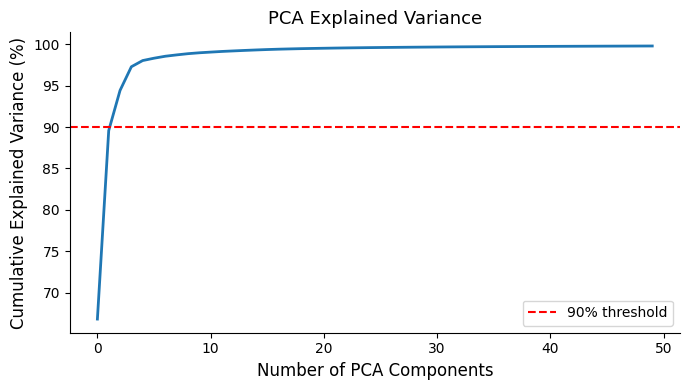

In [29]:
pca_full = decomposition.PCA(n_components=50, whiten=False)
pca_full.fit(embeddings)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.cumsum(pca_full.explained_variance_ratio_) * 100, lw=2)
ax.axhline(90, color='r', linestyle='--', label='90% threshold')
ax.set_xlabel('Number of PCA Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_title('PCA Explained Variance', fontsize=13)
ax.legend()
ax.spines[['right','top']].set_visible(False)
plt.tight_layout()
plt.show()

## Overlaying Meta Information on t-SNE Projections

To understand what the model has learned, we colour the same t-SNE projection by different attributes (density label, prediction correctness, laterality, view, cancer status, and implant presence). If the embedding space is organised primarily by density, other attributes should show no clear structure. Any unexpected clustering by a non density attribute would suggest the model has picked up spurious correlations.


In [30]:
class_columns = [col for col in df.columns if col.startswith('class_')]

df['pred_class'] = np.argmax(
    np.stack([df[c] for c in class_columns]).T, axis=1
)
df['correct'] = (df['pred_class'] == df['target']).map({False: 'Wrong', True: 'Correct'})

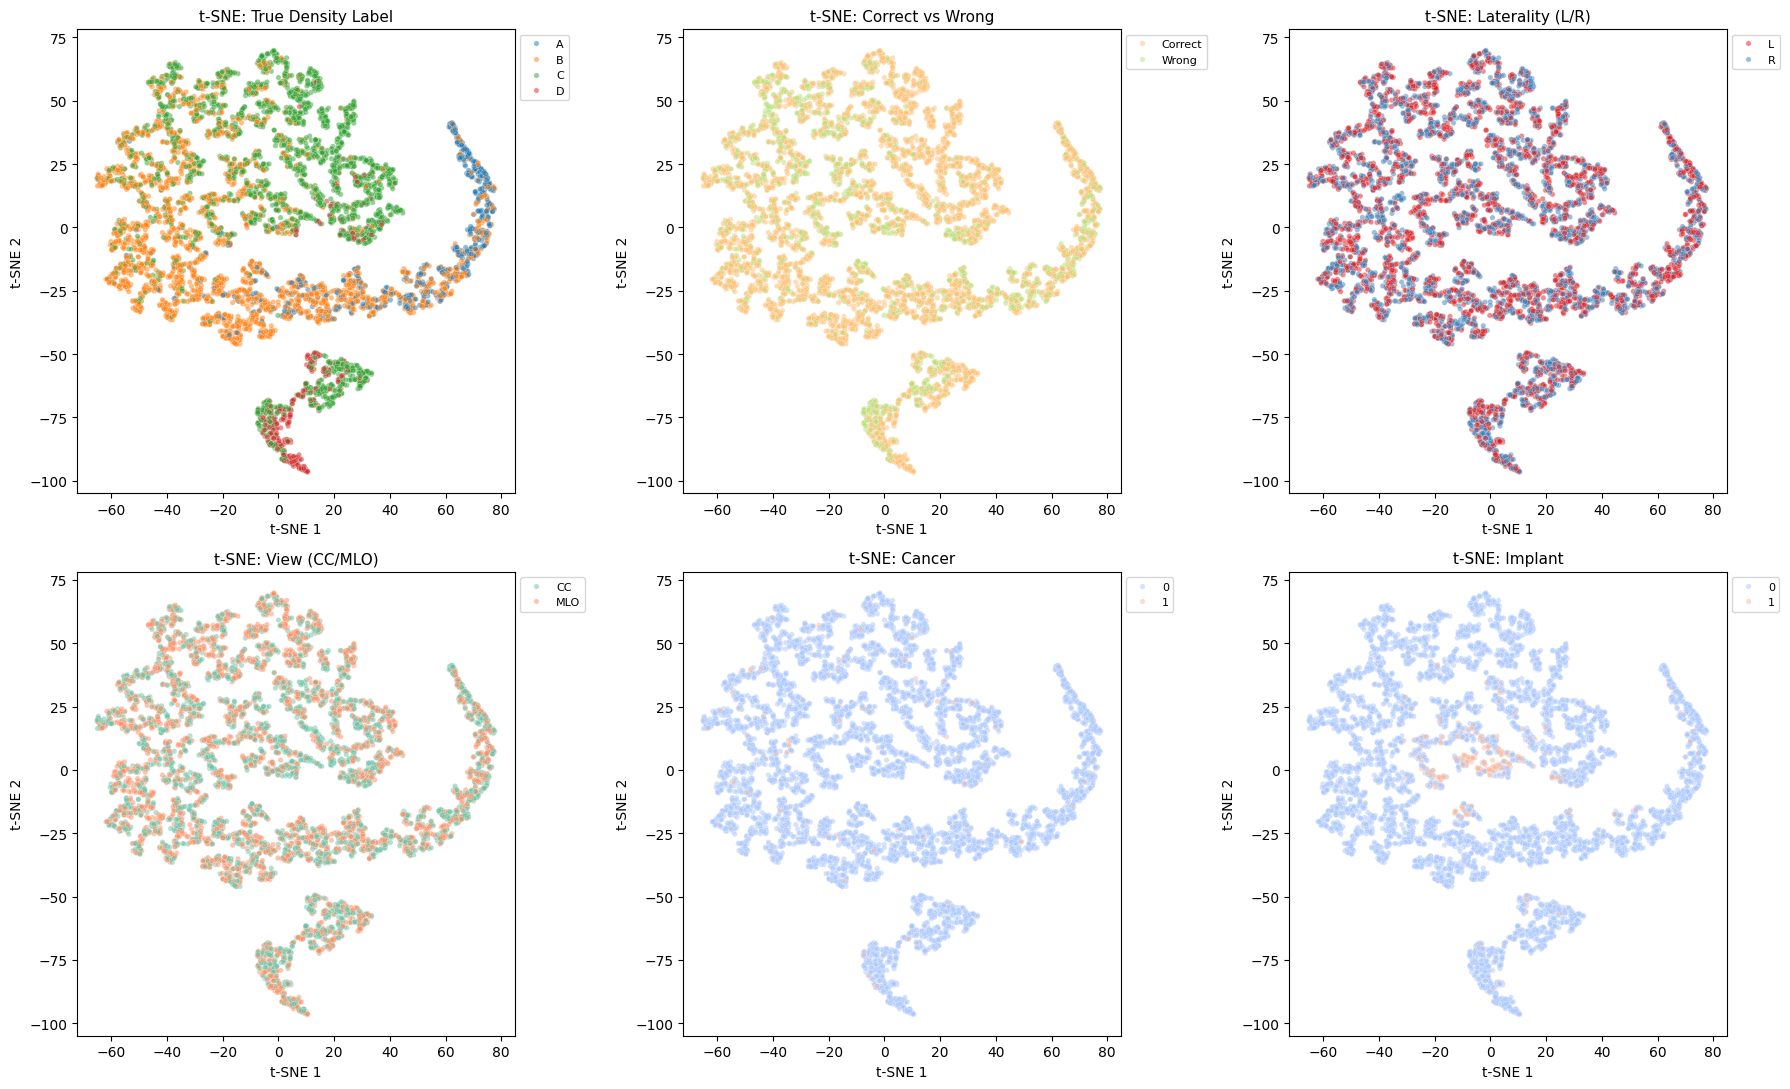

In [31]:
overlays = [
    ('density',    'tab10', 'True Density Label'),
    ('correct',    'RdYlGn', 'Correct vs Wrong'),
    ('laterality', 'Set1',  'Laterality (L/R)'),
    ('view',       'Set2',  'View (CC/MLO)'),
    ('cancer',     'coolwarm', 'Cancer'),
    ('implant',    'coolwarm', 'Implant'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, (hue, palette, title) in zip(axes.flat, overlays):
    hue_order = sorted(df[hue].dropna().unique())
    sns.scatterplot(data=df, x='tsne_1', y='tsne_2', hue=hue,
                    hue_order=hue_order, alpha=0.5, s=15,
                    palette=palette, ax=ax)
    ax.set_title(f't-SNE: {title}', fontsize=11)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

## Comparing PCA and t-SNE Projections

We plot both dimensionality reduction techniques side by side, coloured by density class. PCA is a linear method and shows the directions of maximum variance, while t-SNE is non linear and better preserves local neighbourhood structure. Comparing the two will suggest whether the class separation seen in one projection is consistent across both methods.


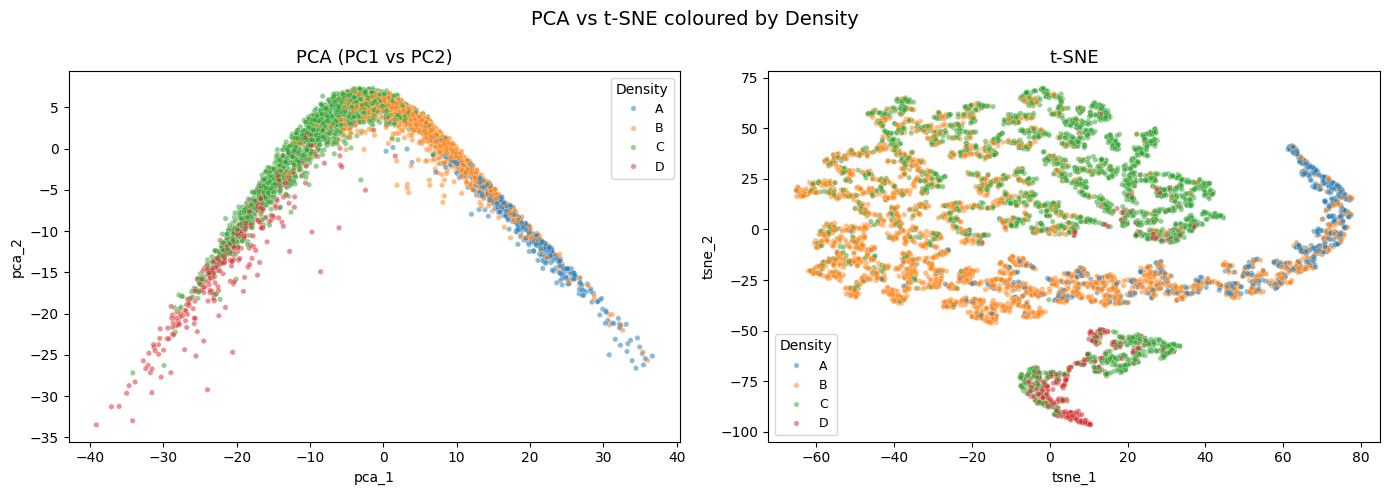

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, x_col, y_col, title in [
    (ax1, 'pca_1', 'pca_2', 'PCA (PC1 vs PC2)'),
    (ax2, 'tsne_1', 'tsne_2', 't-SNE'),
]:
    hue_order = sorted(df['density'].unique())
    sns.scatterplot(data=df, x=x_col, y=y_col, hue='density',
                    hue_order=hue_order, alpha=0.5, s=15,
                    palette='tab10', ax=ax)
    ax.set_title(title, fontsize=13)
    ax.legend(title='Density', fontsize=9)

plt.suptitle('PCA vs t-SNE coloured by Density', fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
alpha = 0.6
style = '.'
markersize = 40
color_palette = 'tab10'
kind = 'scatter'

def plot_scatter(data, hue, x, y, palette):
    hue_order = list(data[hue].unique())
    hue_order.sort()
    sns.set_theme(style="white")
    ax = sns.scatterplot(data=data, x=x, y=y, hue=hue, hue_order=hue_order, alpha=alpha, marker=style, s=markersize, palette=palette)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

def plot_joint(data, hue, x, y, palette):
    hue_order = list(data[hue].unique())
    hue_order.sort()
    sns.set_theme(style="white")
    ax = sns.jointplot(data=data, x=x, y=y, hue=hue, hue_order=hue_order, alpha=alpha, marker=style, s=markersize, palette=palette, marginal_kws={'common_norm': False})
    sns.move_legend(ax.ax_joint, "upper left", bbox_to_anchor=(1.2, 1))

In [34]:
x = 'pca_1'
y = 'pca_2'

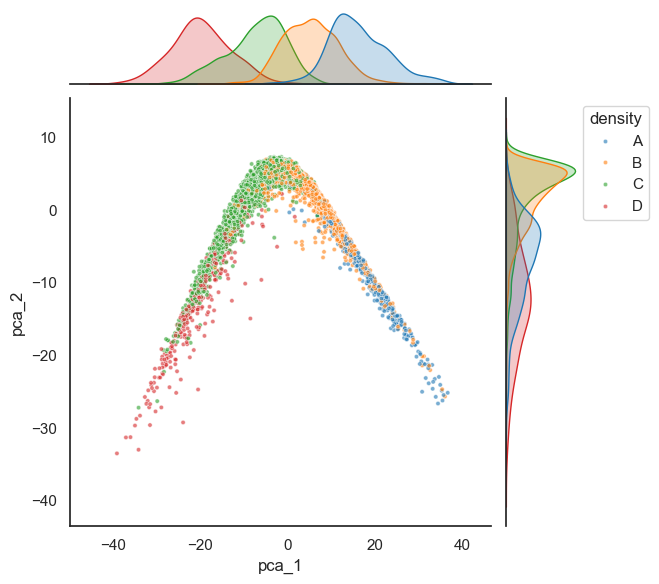

In [35]:
plot_joint(df, 'density', x, y, color_palette)

### Interactive visualisation

With the code below you can interactively explore the latent space to better understand how samples are distributed. You can modify the code to overlay different types of meta information.

In [36]:
df["image_path"] = [
    os.path.join("images", str(df.study_id.values[idx]), str(df.image_id.values[idx]) + ".png")
    for idx in range(len(df))
]

df['color_label'] = 0
df.loc[df['density'] == 'A', 'color_label'] = 0
df.loc[df['density'] == 'B', 'color_label'] = 1
df.loc[df['density'] == 'C', 'color_label'] = 2
df.loc[df['density'] == 'D', 'color_label'] = 3

In [37]:
def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(rgb[0], rgb[1], rgb[2])

color = cm.tab10(np.linspace(0, 1, 10))
colorlist = [(np.array(mpl.colors.to_rgb(c))*255).astype(int).tolist() for c in color]*10

colors = [rgb_to_hex(colorlist[c]) for c in df.color_label.values]

In [38]:
def preprocess(image):
    # breast mask
    image_norm = image - np.min(image)
    image_norm = image_norm / np.max(image_norm)
    thresh = cv2.threshold(img_as_ubyte(image_norm), 5, 255, cv2.THRESH_BINARY)[1]

    # Connected components with stats.
    nb_components, output, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=4)

    # Find the largest non background component.
    # Note: range() starts from 1 since 0 is the background label.
    max_label, _ = max(
        [(i, stats[i, cv2.CC_STAT_AREA]) for i in range(1, nb_components)],
        key=lambda x: x[1],
    )
    mask = output == max_label
    image_masked = image.copy()
    image_masked[mask == 0] = 0

    return image_masked

In [39]:
out = Output()
@out.capture(clear_output=True)
def handle_click(trace, points, state):
    sample = df.iloc[points.point_inds[0]]
    img_orig = imread(os.path.join(DATA_DIR, sample.image_path))
    img_proc = preprocess(img_orig)
    
    s = [6] * len(df)
    for i in points.point_inds:
        s[i] = 12
    with fig.batch_update():
        scatter.marker.size = s

    f, (ax1, ax2) = plt.subplots(1,2, figsize=(8,8))
    ax1.imshow(img_orig, cmap='gray')
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(img_proc, cmap='gray')
    ax2.set_title('processed')
    ax2.axis('off')
    plt.show(f)
    
fig = go.FigureWidget(px.scatter(df, x=x, y=y, template='simple_white', hover_data={'density': True, x:False, y:False}))
fig.update_layout(width=600, height=600)
scatter = fig.data[0]
scatter.on_click(handle_click)
scatter.marker.size = [6] * len(df)
scatter.marker.color = colors

HBox([fig, out])

    'data': [{'customdata': array([['B'],
                                   ['D…